# 이진분류 공부하기 (로지스틱 회귀)
이진 분류(binary classification) : 대상을 True/False로 구분하는 문제

## 초기 인공지능 알고리즘과 로지스틱 회귀

### 1. 퍼셉트론(Perceptron) 알고리즘
 이진 분류 문제에서 최적의 가중치를 학습하는 것이  목적이다.
 구조 : 직선 방정식(선형 함수) -> z -> 계단함수 -> y_hat

### 2. 아달린(Adaline)
 퍼셉트론을 개선한 적응현 선형 뉴런(Adaptive Linear Neuron)
 구조 : 선형 함수 <-> z (역방향 계산) <-> 계단함수 -> y_hat

### 3. 로지스틱 회귀(logistic regression)
 선형 함수의 결과물인 z를 임계함수에 보내기 전에 활성화 함수로 변형시킨다.
 구조 : 선형 함수 -> z -> 활성화 함수 -> a (역방향 계산) -> 임계함수 -> y_hat

- 활성화 함수(active function) : 보통 비선형 함수 사용

## 시그모이드 함수
 선형 함수의 결과값인 z를 0~1 사이의 확률값으로 변환한다.

### 시그모이드 함수 만들기 : 오즈 비 > 로짓 함수 > 시그모이드 함수
 1. 오즈 비(odd's ratio): 성공 확률과 실패 확률의 비율을 나타내는 통계
 2. 로짓 함수 (logit function)
 3. 시그모이드 함수 (sigmoid function)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

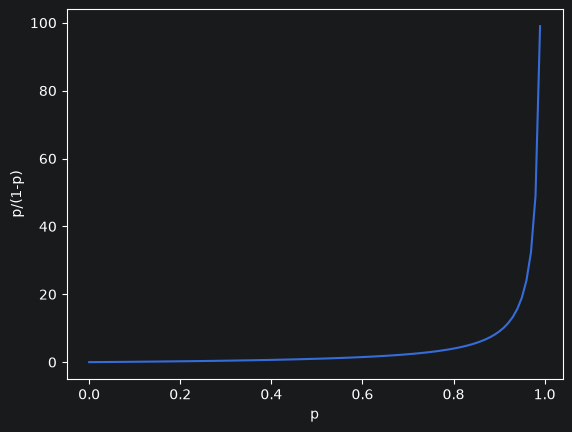

In [2]:
# 1. 오즈 비 만들기
probs = np.arange(0, 1, 0.01) # 성공 확률
odds = [p/(1-p) for p in probs]
plt.plot(probs, odds)
plt.xlabel('p')
plt.ylabel('p/(1-p)')
plt.show()

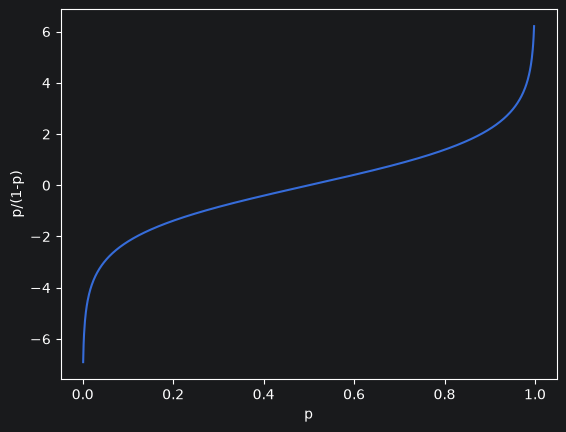

In [3]:
# 2. 로짓 함수 만들기
probs  = np.arange(0.001, 0.999, 0.001)
logit = [np.log(p/(1-p)) for p in probs]
plt.plot(probs, logit)
plt.xlabel('p')
plt.ylabel('p/(1-p)')
plt.show()

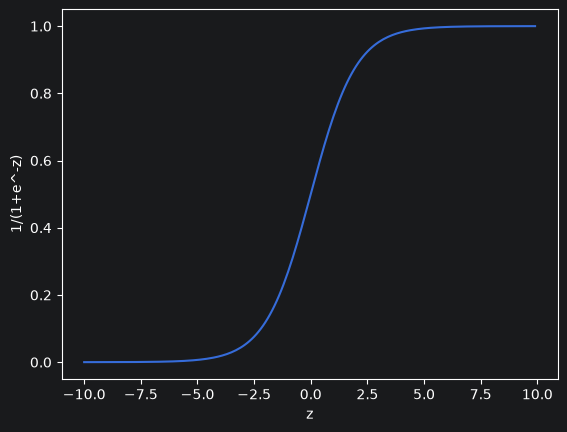

In [4]:
# 3. 시그모이드 함수 만들기
zs = np.arange(-10., 10., 0.1)
gs = [1/(1+np.exp(-z)) for z in zs]
plt.plot(zs, gs)
plt.xlabel('z')
plt.ylabel('1/(1+e^-z)')
plt.show()

In [5]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [6]:
print(cancer.data.shape, cancer.target.shape)

(569, 30) (569,)


In [7]:
cancer.data[:3] # 0, 1, 2 번째 행 출력

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

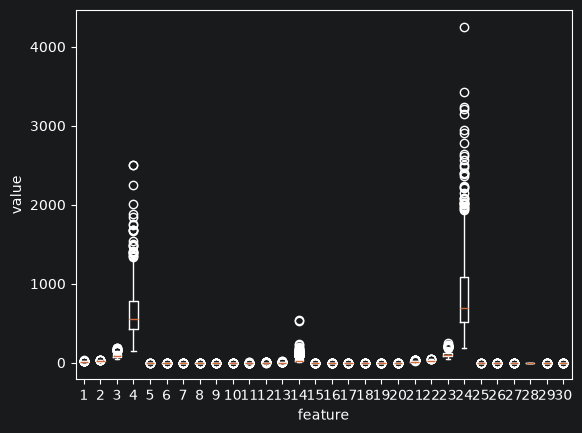

In [8]:
# 박스 플롯 그려서 데이터 파악하기
plt.boxplot(cancer.data)
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

In [9]:
np.unique(cancer.target, return_counts=True) # 0에 대한 counts와 1에 대한 counts 수를 같이 반환하는 옵션

(array([0, 1]), array([212, 357]))

In [10]:
x = cancer.data
y = cancer.target

In [11]:
# 훈련 세트와 테스트 세트 나누기
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [12]:
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(455, 30) (455,) (114, 30) (114,)


In [13]:
np.unique(y_train, return_counts=True)

(array([0, 1]), array([169, 286]))

In [14]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([43, 71]))

In [17]:
# 로지스틱 뉴런 구현하기
class LogisticNeuron:

    def __init__(self):
        self.w = None
        self.b = None

    def forpass(self, x):
        z = np.sum(x*self.w) + self.b # 배열의 크기는 변하지 않고 같은 위치의 원소끼리 더해진다.
        return z

    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z)) # 시그모이드 계산
        return a

    def fit(self, x, y, epochs = 100):
        self.w = np.ones(x.shape[1])
        self.b = 0
        for i in range(epochs):
            for x_i, y_i in zip(x, y):
                z = self.forpass(x_i)
                a = self.activation(z)
                err = -(y_i - a)
                w_grad, b_grad = self.backprop(x_i, err)
                self.w -= w_grad
                self.b -= b_grad


    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]    # 선형함수 적용
        a = self.activation(np.array(z))        # 활성화 함수 적용
        return a > 0.5                          # 계단 함수 적용

In [18]:
neuron = LogisticNeuron()
neuron.fit(x_train, y_train)

In [19]:
np.mean(neuron.predict(x_test) == y_test)

np.float64(0.8333333333333334)

## 로지스틱 회귀로 단일층 신경망 만들기
로지스틱 회귀 뉴런으로 단일층 신경망 만들기
입력층 -> 은닉층 -> 출력층 (은닉층이 1개 이상 있으면 딥러닝, 심층신경망)
- 입력층 : 입력 데이터. 계산이 일어나지 않음. (보통 층이라 지칭할 때는 계산이 일어남)
- 

